In [1]:
import warnings
warnings.filterwarnings("ignore")

## Step 1: Load Pre-split CSVs and Clean Text

In [2]:
import pandas as pd
import re
import string

# ================================
# Dataset Paths
# ================================
TRAIN_CSV = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv"
VAL_CSV   = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv"
TEST_CSV  = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv"

# ================================
# Text Cleaning Functions
# ================================
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_whitespace(text):
    if pd.isna(text):
        return text
    return " ".join(text.split())

def remove_emojis(text):
    if pd.isna(text):
        return text
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_urls(text):
    if pd.isna(text):
        return text
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_html(text):
    if pd.isna(text):
        return text
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub(r'', text)

def remove_special_characters(text):
    if pd.isna(text):
        return text
    return re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF]', '', text)

def clean_text(text):
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    return text

# ================================
# Load & Clean Splits
# ================================
splits = {
    'Train':      TRAIN_CSV,
    'Validation': VAL_CSV,
    'Test':       TEST_CSV,
}

cleaned_paths = {
    'Train':      '/kaggle/working/train_cleaned.csv',
    'Validation': '/kaggle/working/val_cleaned.csv',
    'Test':       '/kaggle/working/test_cleaned.csv',
}

for key, csv_path in splits.items():
    df = pd.read_csv(csv_path)
    df = df[['Title', 'label']]
    df = df.dropna(subset=['label']).reset_index(drop=True)
    df['Title'] = df['Title'].astype(str).apply(clean_text)
    df['label'] = df['label'].astype(int)
    df.to_csv(cleaned_paths[key], index=False)
    print(f"{key} cleaned & saved → {cleaned_paths[key]}")
    print(df['label'].value_counts(), "\n")

Train cleaned & saved → /kaggle/working/train_cleaned.csv
label
0    2886
1    2116
Name: count, dtype: int64 

Validation cleaned & saved → /kaggle/working/val_cleaned.csv
label
0    412
1    303
Name: count, dtype: int64 

Test cleaned & saved → /kaggle/working/test_cleaned.csv
label
0    825
1    605
Name: count, dtype: int64 



In [3]:
train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
train_df.head()

,Title,label
0,ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...,1
1,২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...,0
2,চ্যালেঞ্জ সামলাতে পারবে যুক্তরাষ্ট্রের সাথে সম...,1
3,কুমির চাষে আয় ১৫ কোটি টাকা না দেখলে বিশ্বাস ক...,1
4,আ লীগ নির্বাচনে থাকবে কিনা সিদ্ধান্ত কার ওপর ছ...,0


In [4]:
val_df = pd.read_csv('/kaggle/working/val_cleaned.csv')
val_df.head()

,Title,label
0,হাসিনার প্লট জালিয়াতি ফাঁসছেন ২০ কর্মকর্তা DU...,0
1,কক্সবাজারে এনসিপি নেতাদের গাড়িবহরে হামলা Coxs...,0
2,WBCHSE 2025 Results LIVE উচ্চমাধ্যমিকের ফলাফল ...,0
3,কাল থেকে পুরোদমে শুরু হচ্ছে দেশের শিক্ষা কার্য...,1
4,নবম শ্রেণীর পাঠ্যবই নিয়ে যে তথ্য দিলেন আসিফ ম...,0


In [5]:
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')
test_df.head()

,Title,label
0,অহংকারের পরিণতি কি মুফতি সাইফুল্লাহ মাহমুদআল্ল...,0
1,ইলেকট্রিক কেটলিতে পানি গরম করলে কত টাকা বিদ্যু...,1
2,বনসংরক্ষণ প্রবন্ধ রচনা মাধ্যমিক ও উচ্চমাধ্যমিক...,0
3,টপ ৫ ইতিহাসের সবচেয়ে ভয়াবহ প্রাকৃতিক দুর্যোগ...,1
4,পাকিস্তানিরা কেন শেখ মুজিবের চেয়ে তাজউদ্দীনকে...,1


## Step 2: Install Dependencies

In [6]:
!pip install transformers

## Step 3: Imports & Configuration

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaModel
import pandas as pd
from sklearn.metrics import accuracy_score
import time

# ================================
# Configuration
# ================================
BATCH_SIZE    = 32
MAX_LEN       = 128
LEARNING_RATE = 2e-5
EPOCHS        = 15
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Device:", DEVICE)

Device: cuda


## Step 4: Custom Dataset Class

In [8]:
class ClickbaitDataset(Dataset):
    def __init__(self, csv_path, tokenizer):
        self.data      = pd.read_csv(csv_path)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # ---- Text ----
        title  = str(row['Title'])
        inputs = self.tokenizer(
            title,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # ---- Label ----
        label = torch.tensor(row['label'], dtype=torch.long)

        return {
            'ids':     inputs['input_ids'].flatten(),
            'mask':    inputs['attention_mask'].flatten(),
            'targets': label
        }

## Step 5: Tokenizer

In [9]:
# XLM-RoBERTa tokenizer
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Step 6: DataLoaders

In [10]:
train_dataset = ClickbaitDataset('/kaggle/working/train_cleaned.csv', tokenizer)
val_dataset   = ClickbaitDataset('/kaggle/working/val_cleaned.csv',   tokenizer)
test_dataset  = ClickbaitDataset('/kaggle/working/test_cleaned.csv',  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready.")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

DataLoaders ready.
Train: 5002 | Val: 715 | Test: 1430


## Step 7: Model Architecture (XLM-RoBERTa Unimodal Text)

In [11]:
class XLMRobertaClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(XLMRobertaClassifier, self).__init__()

        # --- Text Branch (XLM-RoBERTa) ---
        self.xlmroberta = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        self.drop       = nn.Dropout(0.3)

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        output    = self.xlmroberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_feat  = output.last_hidden_state[:, 0, :]  # [CLS] token
        cls_feat  = self.drop(cls_feat)
        logits    = self.classifier(cls_feat)
        return logits

## Step 8: Model Initialization

In [12]:
model     = XLMRobertaClassifier(num_classes=2)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("Model initialized on", DEVICE)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model initialized on cuda


## Step 9: Training & Evaluation Functions

In [13]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in dataloader:
        ids     = batch['ids'].to(device)
        mask    = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.cpu().numpy())

    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)


def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            ids     = batch['ids'].to(device)
            mask    = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(ids, mask)
            loss    = criterion(outputs, targets)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(targets.cpu().numpy())

    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)

## Step 10: Training Loop

In [14]:
print("Starting Training...")

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = eval_model(model, val_loader, criterion, DEVICE)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {elapsed:.2f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

torch.save(model.state_dict(), '/kaggle/working/xlmroberta_unimodal.pth')
print("Training complete. Model saved!")

Starting Training...
Epoch 1/15 | Time: 122.79s
  Train Loss: 0.6326 | Train Acc: 0.6327
  Val   Loss: 0.5426 | Val   Acc: 0.7329
----------------------------------------
Epoch 2/15 | Time: 132.89s
  Train Loss: 0.5156 | Train Acc: 0.7639
  Val   Loss: 0.4964 | Val   Acc: 0.7888
----------------------------------------
Epoch 3/15 | Time: 132.57s
  Train Loss: 0.4227 | Train Acc: 0.8241
  Val   Loss: 0.4860 | Val   Acc: 0.7944
----------------------------------------
Epoch 4/15 | Time: 132.98s
  Train Loss: 0.3533 | Train Acc: 0.8591
  Val   Loss: 0.4712 | Val   Acc: 0.8210
----------------------------------------
Epoch 5/15 | Time: 132.75s
  Train Loss: 0.2788 | Train Acc: 0.8962
  Val   Loss: 0.5793 | Val   Acc: 0.7846
----------------------------------------
Epoch 6/15 | Time: 132.74s
  Train Loss: 0.2395 | Train Acc: 0.9104
  Val   Loss: 0.5774 | Val   Acc: 0.8098
----------------------------------------
Epoch 7/15 | Time: 132.91s
  Train Loss: 0.1857 | Train Acc: 0.9344
  Val   Los

## Step 11: Model Evaluation — Confusion Matrix & Classification Report

Generating predictions on Test Set...

          MODEL EVALUATION
                   precision    recall  f1-score   support

Non-Clickbait (0)       0.86      0.82      0.84       825
    Clickbait (1)       0.77      0.82      0.80       605

         accuracy                           0.82      1430
        macro avg       0.82      0.82      0.82      1430
     weighted avg       0.82      0.82      0.82      1430



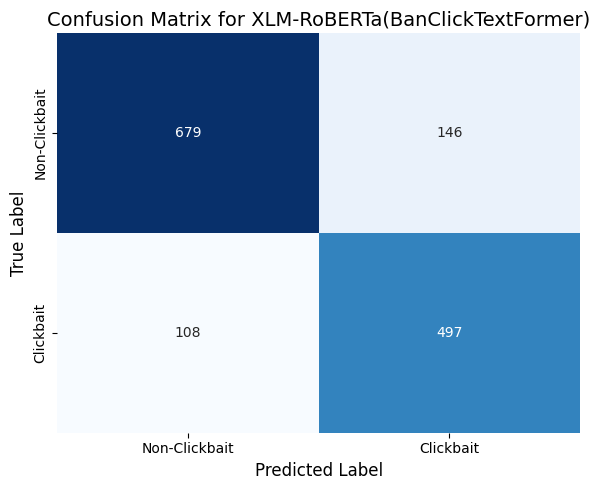


Summary Metrics:
  Accuracy : 0.8224
  Precision: 0.7729
  Recall   : 0.8215
  F1 Score : 0.7965


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

def get_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    print("Generating predictions on Test Set...")
    with torch.no_grad():
        for batch in dataloader:
            ids     = batch['ids'].to(device)
            mask    = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(ids, mask)
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(targets.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(model, test_loader, DEVICE)

# Classification Report
print("\n" + "="*40)
print("          MODEL EVALUATION")
print("="*40)
print(classification_report(y_true, y_pred, target_names=['Non-Clickbait (0)', 'Clickbait (1)']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for XLM-RoBERTa(BanClickTextFormer)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print(f"\nSummary Metrics:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1 Score : {f1:.4f}")

## Step 12: ROC Curve

Computing probabilities for ROC curve...
AUC Score: 0.8906


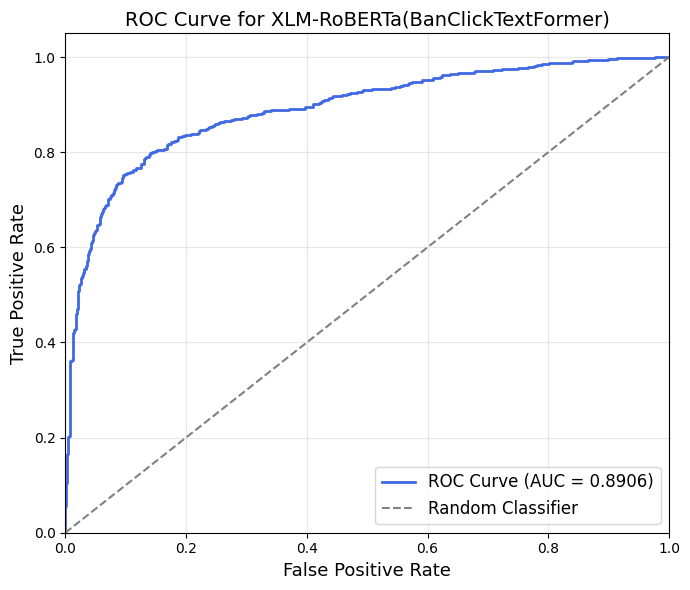

ROC curve saved to /kaggle/working/roc_curve.png


In [16]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, roc_auc_score

def get_probabilities(model, dataloader, device):
    """Returns true labels and predicted probabilities for the positive class."""
    model.eval()
    all_probs, all_labels = [], []

    print("Computing probabilities for ROC curve...")
    with torch.no_grad():
        for batch in dataloader:
            ids     = batch['ids'].to(device)
            mask    = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            logits = model(ids, mask)
            probs  = F.softmax(logits, dim=1)[:, 1]  # probability of Clickbait class

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


y_true_roc, y_prob = get_probabilities(model, test_loader, DEVICE)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true_roc, y_prob)
auc_score = roc_auc_score(y_true_roc, y_prob)

print(f"AUC Score: {auc_score:.4f}")

# Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve for XLM-RoBERTa(BanClickTextFormer)', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

print("ROC curve saved to /kaggle/working/roc_curve.png")